# Getting Started with Kompot

This tutorial introduces Kompot's core functionality for differential analysis in single-cell data. You'll learn how to:

- Perform differential abundance (DA) analysis to identify cell states that change between conditions
- Conduct differential expression (DE) analysis to find genes with altered expression
- Visualize and interpret results using Kompot's plotting tools

## What Makes Kompot Different?

Kompot uses **Mahalanobis distance** to detect expression differences while accounting for the covariance structure of gene expression. This approach is particularly powerful for:

- Detecting subtle changes along continuous cell state trajectories
- Identifying genes with complex, coordinated expression patterns
- Analyzing data where discrete cell type labels are inadequate

## Dataset

We'll analyze murine bone marrow cells comparing Young vs. Old mice to understand how aging affects hematopoietic stem cells and their derivatives.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc
import seaborn as sns

import kompot

# Set plotting style
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

## Configuration

Define analysis parameters. Adapt these to your own data:

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"              # Condition column in adata.obs
CONDITIONS = ["Young", "Old"]        # First condition is reference
CELL_TYPE_COLUMN = "highres_celltype"  # Optional: for visualization only
DIMENSIONALITY_REDUCTION = "X_pca_harmony"  # Cell state representation
LAYER_FOR_EXPRESSION = "logged_counts"        # Expression data layer

## Load Data

The dataset will be downloaded automatically from Zenodo if not already present:

In [3]:
import os
from pathlib import Path
import requests
from tqdm.auto import tqdm

Path(DATA_PATH).parent.mkdir(parents=True, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Downloading dataset...")
    url = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"
    response = requests.get(url, stream=True)
    total = int(response.headers.get("content-length", 0))
    
    with open(DATA_PATH, "wb") as file, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))

adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

## Data Exploration

Before analysis, examine the data structure and distribution:

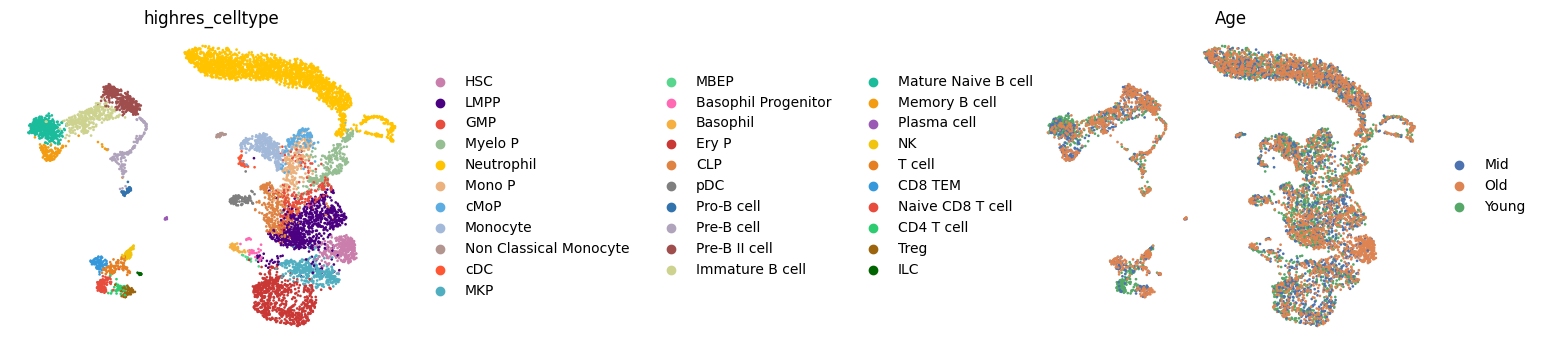

In [4]:
sc.pl.umap(adata, color=[CELL_TYPE_COLUMN, GROUPING_COLUMN], frameon=False, wspace=1.3)

If you have a clustering or cell-type annotation, cell type composition can provide a rough understanding of the data and help identify underrepresented cell types that could complicate differential expression analysis.

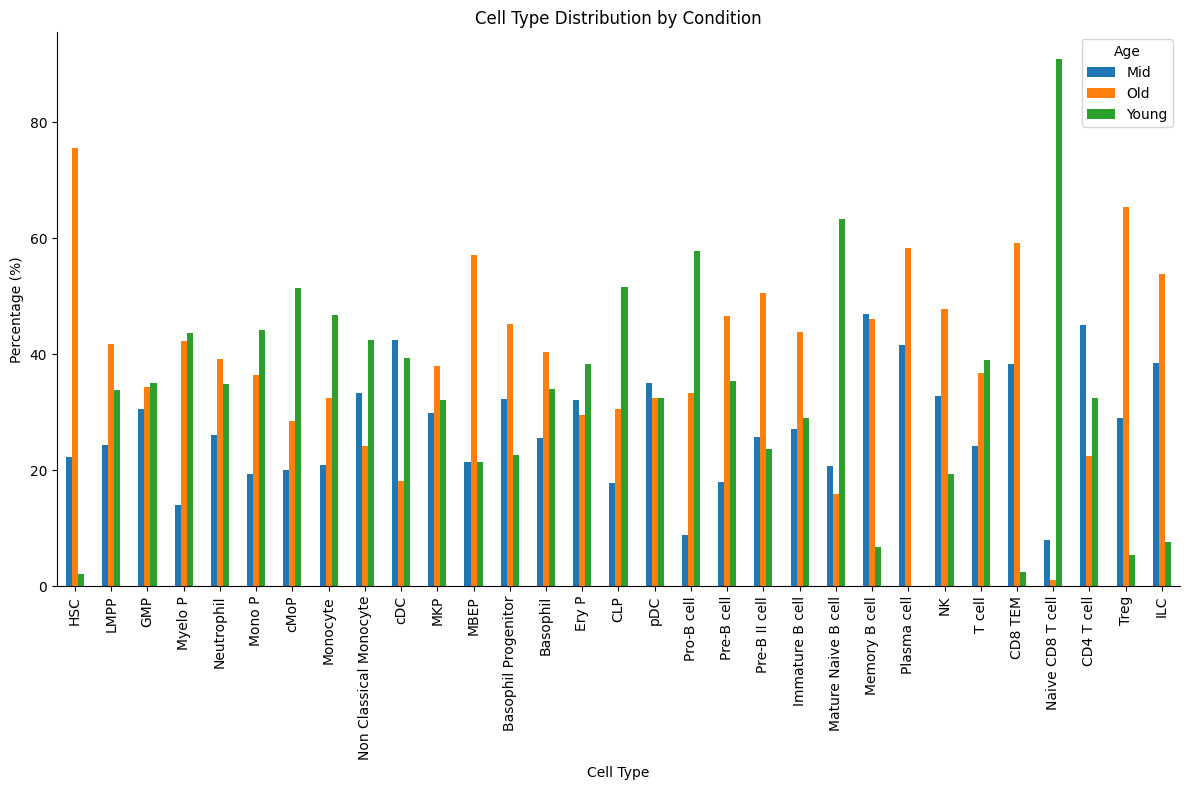

Cell types with >=75% bias toward one condition:
Age                     Mid        Old      Young
highres_celltype                                 
HSC               22.257053  75.548589   2.194357
Naive CD8 T cell   8.000000   1.000000  91.000000

These cell types might show disproportionate changes between conditions.


In [5]:
crosstab = (
    pd.crosstab(
        adata.obs[CELL_TYPE_COLUMN], adata.obs[GROUPING_COLUMN], normalize="index"
    )
    * 100
)

# Plot the distribution
ax = crosstab.plot(kind="bar", stacked=False, figsize=(12, 8))
ax.grid(False)
plt.xlabel("Cell Type")
plt.ylabel("Percentage (%)")
plt.title("Cell Type Distribution by Condition")
plt.legend(title=GROUPING_COLUMN)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Print extremes (cell types with high bias toward one condition)
bias_threshold = 75  # Percentage threshold for considering a cell type biased
biased_types = crosstab[(crosstab > bias_threshold).any(axis=1)]

if not biased_types.empty:
    print(f"Cell types with >={bias_threshold}% bias toward one condition:")
    print(biased_types)
    print("\nThese cell types might show disproportionate changes between conditions.")

## Diffusion Maps Preprocessing

Kompot requires a continuous representation of cell states. [Palantir diffusion maps](https://github.com/dpeerlab/Palantir) capture the geometry of differentiation trajectories while reducing noise:

In [6]:
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40);

## Differential Abundance Analysis

Identify cell states that change in frequency between conditions.

See [kompot.compute_differential_abundance](https://kompot.readthedocs.io/en/latest/simplified.html#kompot.compute_differential_abundance) for full documentation.

In [7]:
da_results = kompot.compute_differential_abundance(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    obsm_key=DIMENSIONALITY_REDUCTION,
)

[2026-03-05 15:40:37,836] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-05 15:40:37,836] [INFO    ] Condition 2 (Old): 3,116 cells
[2026-03-05 15:40:37,838] [INFO    ] Fitting density estimator for condition 1...


W0305 15:40:44.183013 23471665 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


[2026-03-05 15:40:49,086] [INFO    ] Fitting density estimator for condition 2...
[2026-03-05 15:40:56,104] [INFO    ] This run will have `run_id=0`.


### Visualize Abundance Changes

Results are stored in `adata.obs`:
- `kompot_da_Young_to_Old_lfc`: Log fold change (positive = enriched in Old)
- `kompot_da_Young_to_Old_lfc_direction`: Categorical classification (up/down/unchanged)

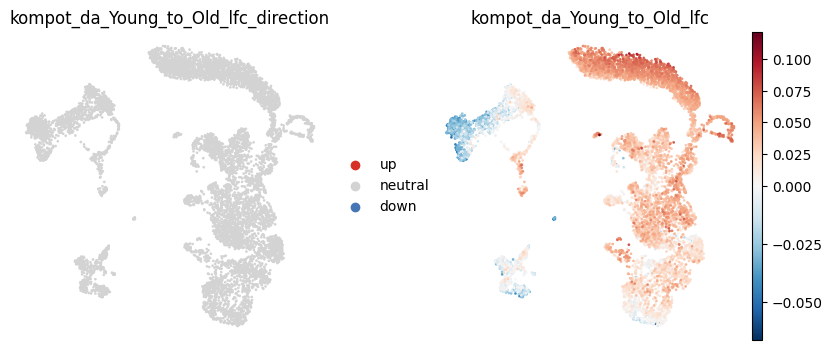

In [8]:
sc.pl.embedding(
    adata, "umap",
    color=[f"kompot_da_{CONDITIONS[0]}_to_{CONDITIONS[1]}_lfc_direction", f"kompot_da_{CONDITIONS[0]}_to_{CONDITIONS[1]}_lfc"],
    color_map="RdBu_r",
    vcenter=0,
    frameon=False,
)

### Volcano Plot

[Volcano plots for differential abundance](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.volcano_da) show effect size (x-axis) vs. statistical significance (y-axis):

[2026-03-05 15:40:56,211] [INFO    ] Found DA run info for run_id=-1
[2026-03-05 15:40:56,212] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2026-03-05 15:40:56,212] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info
[2026-03-05 15:40:56,213] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}
[2026-03-05 15:40:56,213] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05


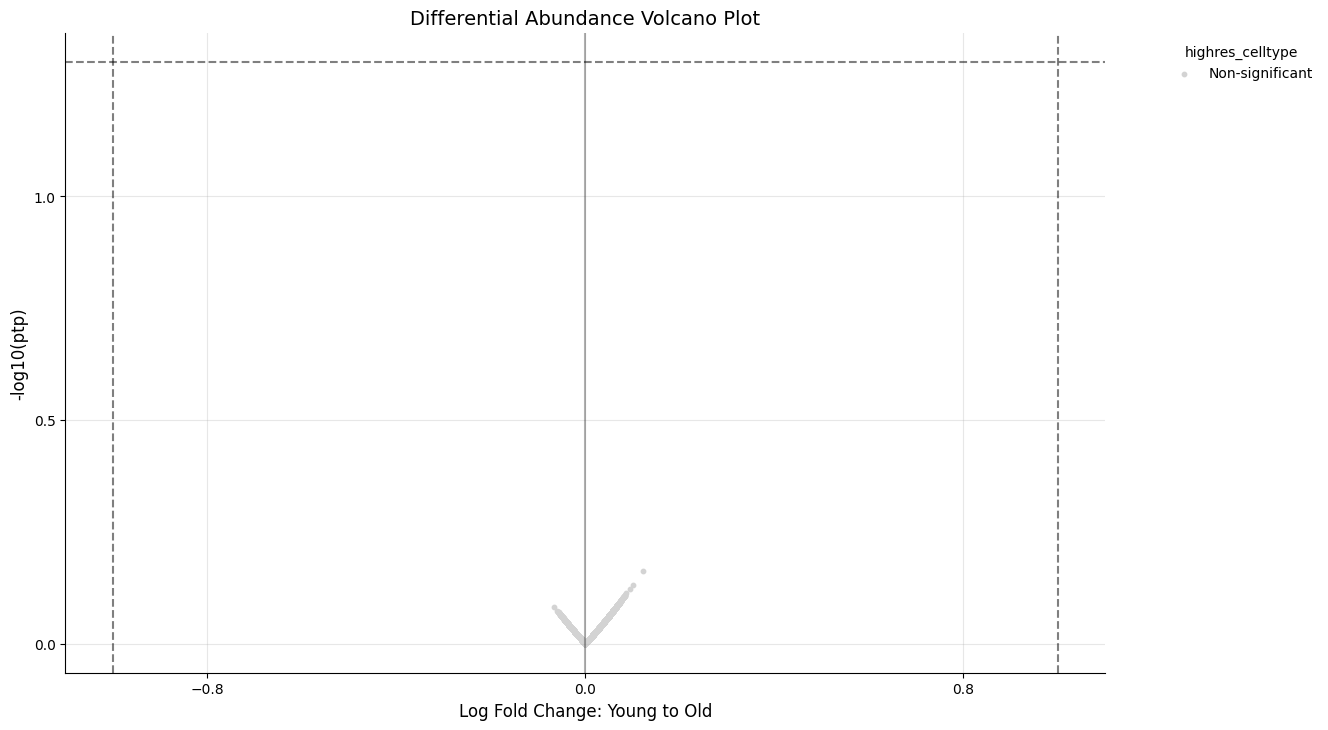

In [9]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN)

Points above the horizontal line and outside vertical lines are significantly changed.

Adjust thresholds using `ptp_threshold` and `lfc_threshold` parameters. Use `update_direction=True` to update the classification in `adata.obs`.

In [10]:
# Visualize only significantly changed cells
kompot.plot.embedding(
    adata, "umap",
    color=[CELL_TYPE_COLUMN, f"kompot_da_{CONDITIONS[0]}_to_{CONDITIONS[1]}_lfc"],
    groups={f"kompot_da_{CONDITIONS[0]}_to_{CONDITIONS[1]}_lfc_direction": ["up", "down"]},
    frameon=False,
    wspace=.5,
)

[2026-03-05 15:40:56,270] [INFO    ] Selected 0 cells out of 8,090 total cells.
[2026-03-05 15:40:56,271] [WARNING ] No cells match the filtering criteria. Check your group filters.


The `mgroups` parameter in the [kompot.plot.embedding](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.embedding) function allows plotting increasing and decreasing cell types separately:

[2026-03-05 15:40:56,279] [INFO    ] Selected 0 cells out of 8,090 total cells.
[2026-03-05 15:40:56,280] [WARNING ] No cells match the filtering criteria. Check your group filters.
[2026-03-05 15:40:56,282] [INFO    ] Selected 0 cells out of 8,090 total cells.
[2026-03-05 15:40:56,282] [WARNING ] No cells match the filtering criteria. Check your group filters.


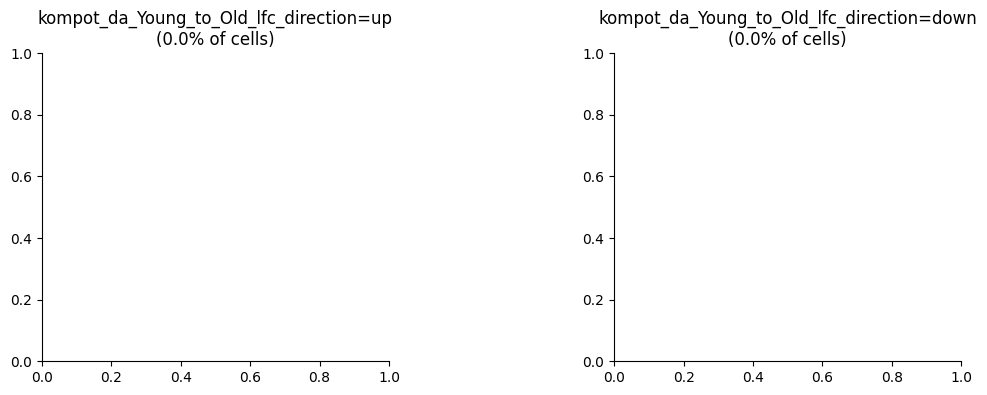

In [11]:
kompot.plot.embedding(
    adata,
    "umap",
    color=CELL_TYPE_COLUMN,
    mgroups=[{f"kompot_da_{CONDITIONS[0]}_to_{CONDITIONS[1]}_lfc_direction":[d]} for d in ["up", "down"]],
    frameon=False,
    wspace=.5,
)

### Summary by Cell Type

Aggregate abundance changes by cell type with the [direction_barplot](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.direction_barplot):

[2026-03-05 15:40:56,328] [INFO    ] Found DA run info for run_id=-1
[2026-03-05 15:40:56,328] [INFO    ] Found direction_key='kompot_da_Young_to_Old_lfc_direction' from run info
[2026-03-05 15:40:56,329] [INFO    ] Successfully inferred fields: {'direction_key': 'kompot_da_Young_to_Old_lfc_direction'}
[2026-03-05 15:40:56,329] [INFO    ] Using DA run 0 for direction_barplot: comparing Young to Old
[2026-03-05 15:40:56,329] [INFO    ] Creating direction barplot: comparing Young to Old
[2026-03-05 15:40:56,330] [INFO    ] Using fields - category_column: 'highres_celltype', direction_column: 'kompot_da_Young_to_Old_lfc_direction'


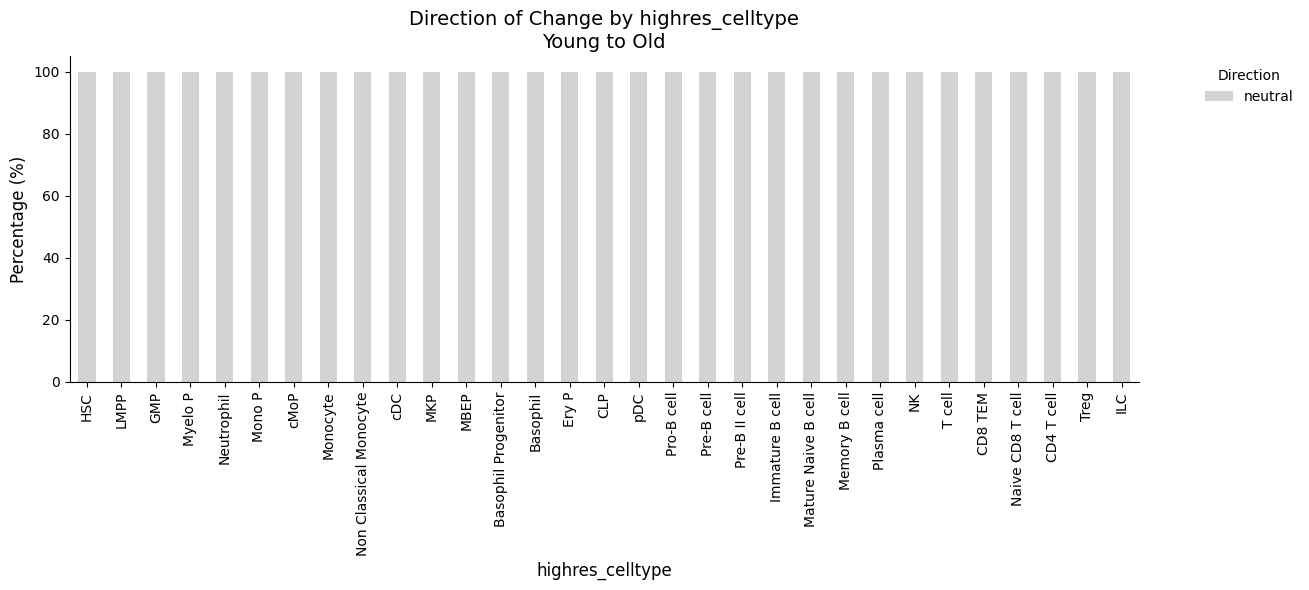

In [12]:
kompot.plot.direction_barplot(adata, category_column=CELL_TYPE_COLUMN)

## Differential Expression Analysis

Identify genes that change in expression between conditions.

See [kompot.de](https://kompot.readthedocs.io/en/latest/simplified.html#kompot.de) for full documentation.

In [ ]:
de_results = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(use_empirical_variance=True),
    output=kompot.OutputSettings(progress=False),
)

### Resource Planning

For larger datasets or production workflows, you may want to optimize memory usage and computational resources. See the [Resource Planning section](https://kompot.readthedocs.io/en/latest/notebooks/02_differential_expression_detailed.html#Resource-Planning) in Tutorial 2 for more detailed guidance.

### Results Interpretation

Results are stored in `adata.var`:

- `kompot_de_Young_to_Old_mean_lfc`: Average log fold change
- `kompot_de_Young_to_Old_mahalanobis`: Statistical significance (higher = more significant)
- `kompot_de_Young_to_Old_is_de`: Boolean flag for significant genes (FDR < 0.05)

The Mahalanobis distance accounts for covariance structure and is more sensitive than simple fold change.

In [14]:
# Top differentially expressed genes
adata.var.loc[
    :, adata.var.columns.str.contains("kompot_de")
].sort_values(
    f"kompot_de_{CONDITIONS[0]}_to_{CONDITIONS[1]}_mahalanobis", ascending=False
).head(20)

,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis_local_fdr,kompot_de_Young_to_Old_is_de
H2-Q7,0.487948,0.390195,0.0,True
Aldh1a1,0.460025,0.170122,0.0,True
B2m,0.397629,0.127136,0.0,True
H2-D1,0.390418,0.126297,0.0,True
H2-Q6,0.380160,0.254769,0.0,True
Plscr2,0.365241,0.096781,0.0,True
AW112010,0.363749,0.270751,0.0,True
Clec1a,0.358045,0.098766,0.0,True
Iigp1,0.346992,0.126983,0.0,True
Cirbp,0.320884,0.213582,0.0,True


### Volcano Plot

Visualize effect size vs. significance for differential expression with the [volcano_de plot](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.volcano_de):

[2026-03-05 15:42:31,728] [INFO    ] Found DE run info for run_id=-1
[2026-03-05 15:42:31,729] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-05 15:42:31,729] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-05 15:42:31,730] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-05 15:42:31,730] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-05 15:42:31,734] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'
[2026-03-05 15:42:31,737] [INFO    ] Highlighting 1,435 genes marked as DE (1000 up, 435 down)
[2026-03-05 15:42:31,745] [INFO    ] Labeling top 10 genes by score


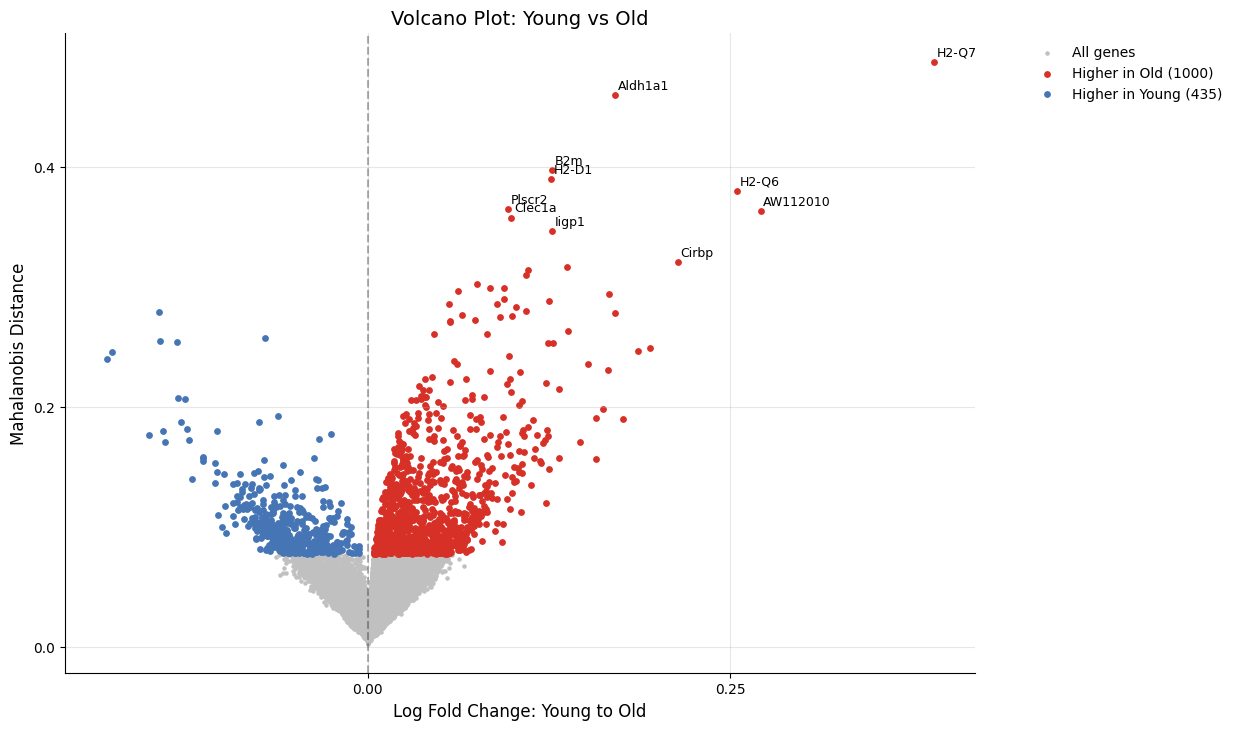

In [15]:
kompot.plot.volcano_de(adata)

### Fold Change Heatmap

Visualize fold changes across top differentially expressed genes with a heatmap. This provides a complementary view to the volcano plot, showing the magnitude and direction of expression changes.

Note that the gene selection is based on Kompot's Mahalanobis distance (statistical significance), but the fold changes displayed are simply the difference of mean expressions from the input expression layer (in this case `logged_counts`), not a Kompot-specific metric:

[2026-03-05 15:42:31,832] [INFO    ] Inferred condition_column='Age' from run information
[2026-03-05 15:42:31,832] [INFO    ] Inferred condition1='Young' from run information
[2026-03-05 15:42:31,832] [INFO    ] Inferred condition2='Old' from run information
[2026-03-05 15:42:31,832] [INFO    ] Inferred layer='logged_counts' from run information
[2026-03-05 15:42:31,833] [INFO    ] Creating fold change heatmap with 20 genes/features
[2026-03-05 15:42:31,833] [INFO    ] Using expression data from layer: 'logged_counts'
[2026-03-05 15:42:31,866] [INFO    ] Excluded 7 cells from groups: Plasma cell
[2026-03-05 15:42:31,868] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')
[2026-03-05 15:42:31,887] [WARNING ] standard_scale is ignored in fold_change_mode as z-scoring is not appropriate for fold changes


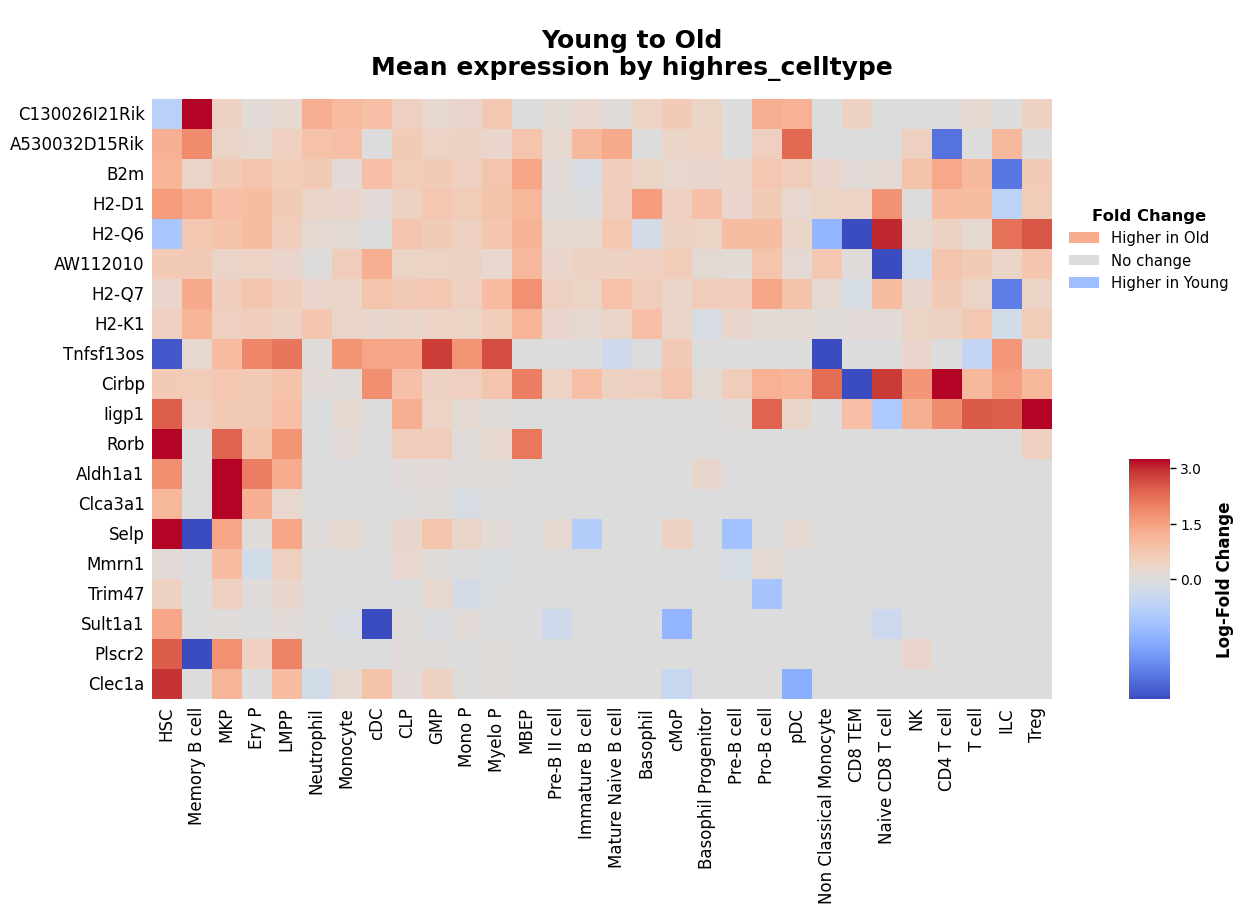

In [16]:
# Selecting top 20 genes
genes = adata.var[f"kompot_de_{CONDITIONS[0]}_to_{CONDITIONS[1]}_mahalanobis"].sort_values(ascending=False).head(20).index

kompot.plot.heatmap(
    adata,
    genes=genes,
    groupby=CELL_TYPE_COLUMN,        # Aggregate expression by cell type
    exclude_groups="Plasma cell",    # Remove cell types with too little representation
    vmin="p1",                       # Color scale minimum at 1st percentile (handles outliers)
    vmax="p99",                      # Color scale maximum at 99th percentile
    fold_change_mode=True,           # Display fold changes instead of mean expression
)

[2026-03-05 15:51:36,273] [INFO    ] Found DE run info for run_id=-1
[2026-03-05 15:51:36,273] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-05 15:51:36,274] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-05 15:51:36,275] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-05 15:51:36,276] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-05 15:51:36,277] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_Young_to_Old_mean_lfc', score_key: 'kompot_de_Young_to_Old_mahalanobis'
[2026-03-05 15:51:36,277] [INFO    ] Using layer 'logged_counts' inferred from run information
[2026-03-05 15:51:36,278] [INFO    ] Using imputed layer 'kompot_de_Young_imputed' for 'Young'
[2026-03-05 15:51:36,278] [INFO    ] Using imputed layer 'kompot_de_Old_imputed' for 'Old'
[2026-03-05 15:

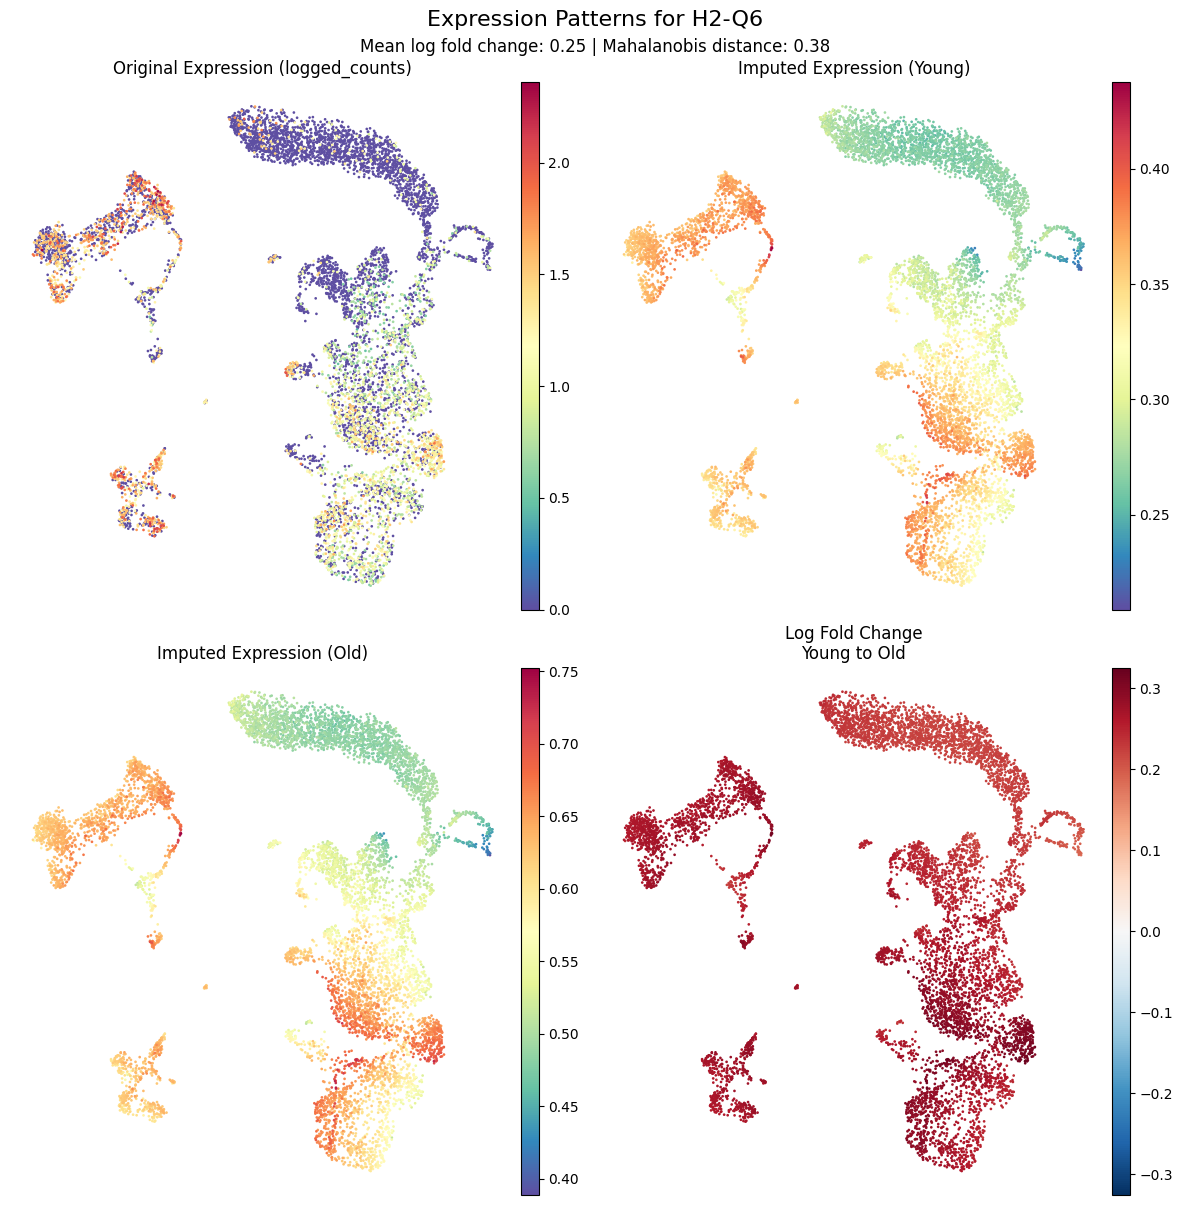

In [20]:
kompot.plot.plot_gene_expression(
    adata, gene="H2-Q6", frameon=False
)

### Functional Enrichment

Use [StringDBReport](https://kompot.readthedocs.io/en/latest/plotting.html#stringdb-integration) to analyze gene sets using [STRING database](https://string-db.org/):

> **Privacy Note**: This sends gene lists to the STRING database API. If working with sensitive data, consider local alternatives.

In [24]:
# Selecting top 20 genes
gene = adata.var[f"kompot_de_{CONDITIONS[0]}_to_{CONDITIONS[1]}_mahalanobis"].sort_values(ascending=False).head(200).index

# Create STRING report (10090 = Mus musculus, 9606 = Homo Sapiens)
report = kompot.plot.StringDBReport(
    gene, 
    species_id=10090, 
    include_enrichment=True
)
report

Gene,Resource Links
H2-Q7,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Aldh1a1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
B2m,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
H2-D1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
H2-Q6,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Plscr2,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
AW112010,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Clec1a,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Iigp1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Cirbp,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene


In [22]:
# Get enriched functional categories
report.get_functional_enrichment("Function").head(10)

,category,term,number_of_genes,number_of_genes_in_background,ncbiTaxonId,inputGenes,preferredNames,p_value,fdr,description,expected,strength,signal
63,Function,GO:0062061,3,5,10090,"[H2-K1, H2-Q6, H2-D1]","[H2-K1, H2-Q6, H2-D1]",2.620000e-08,0.000032,TAP complex binding,0.004545,2.819544,1.000000
59,Function,GO:0042610,4,24,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",6.510000e-09,0.000032,CD8 receptor binding,0.021818,2.263241,0.434783
55,Function,GO:0030881,4,25,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",7.550000e-09,0.000032,beta-2-microglobulin binding,0.022727,2.245513,0.421053
62,Function,GO:0046979,4,25,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",7.550000e-09,0.000032,TAP2 binding,0.022727,2.245513,0.421053
61,Function,GO:0046978,4,26,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",8.700000e-09,0.000032,TAP1 binding,0.023636,2.228479,0.408163
57,Function,GO:0042605,4,31,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",1.660000e-08,0.000032,Peptide antigen binding,0.028182,2.152091,0.353982
58,Function,GO:0042608,4,31,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",1.660000e-08,0.000032,T cell receptor binding,0.028182,2.152091,0.353982
60,Function,GO:0046703,4,34,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",2.330000e-08,0.000032,Natural killer cell lectin-like receptor binding,0.030909,2.111974,0.327869
56,Function,GO:0042288,4,41,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",4.700000e-08,0.000032,MHC class I protein binding,0.037273,2.030669,0.279720
64,Function,GO:0071889,4,55,10090,"[H2-K1, H2-Q7, H2-Q6, H2-D1]","[H2-K1, H2-Q7, H2-Q6, H2-D1]",1.420000e-07,0.000058,14-3-3 protein binding,0.050000,1.903090,0.214784


## Inspecting Run History with RunInfo

Kompot tracks the history of all differential analysis runs, including parameters, environment, and results. The `RunInfo` class provides easy access to this information:

See [kompot.RunInfo](https://kompot.readthedocs.io/en/latest/anndata.html#kompot.anndata.utils.RunInfo) for full documentation.

In [ ]:
# Get info about the most recent DE run
de_run = kompot.RunInfo(adata, analysis_type='de')
de_run

## Saving Results

### Optional: Cleanup Large Layers

Imputed expression layers can be large. Remove them if not needed for further analysis with the [cleanup utility](https://kompot.readthedocs.io/en/latest/anndata.html#kompot.cleanup):

In [ ]:
kompot.cleanup(adata)

This removes:
- `kompot_de_Young_imputed`
- `kompot_de_Old_imputed`
- `kompot_de_Young_to_Old_fold_change`

Statistical results in `adata.var` and `adata.obs` are preserved.

In [ ]:
adata.write_h5ad("../data/murine_bone_marrow_aging_processed.h5ad")

## Biological Interpretation

### Key Findings

**Differential Abundance:**
- HSCs show increased abundance in Old mice
- Naive CD8 T cells are predominantly Young
- Consistent with age-related HSC expansion and T cell depletion

**Differential Expression:**
- **MHC class II genes** (H2-Q7, Cd74, H2-Aa, H2-Ab1): Upregulated in Old mice → enhanced antigen presentation
- **Antioxidant genes** (S100a8, S100a9, Apoe): Higher in Young → reduced oxidative stress
- **Interferon-stimulated genes** (Ifitm family): Age-related changes in immune response

These patterns suggest aging leads to chronic immune activation ("inflammaging") and altered stem cell dynamics.

## Next Steps

- **Tutorial 2**: [Differential Expression Deep Dive](./02_differential_expression_detailed.ipynb) - Advanced DE analysis options
- **Tutorial 3**: [Sample Variance Analysis](./03_sample_variance.ipynb) - Account for biological replicates

For complete documentation, visit [kompot.readthedocs.io](https://kompot.readthedocs.io)